In [1]:
import sys
!{sys.executable} -m pip install pyspark pandas matplotlib seaborn scikit-learn plotly

In [2]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("Tennis Big Data Prediction") \
    .config("spark.sql.shuffle.partitions", "8") \
    .getOrCreate()

print("Spark initialized successfully")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/06/07 13:07:39 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark initialized successfully


In [3]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("Tennis Big Data Prediction") \
    .config("spark.sql.shuffle.partitions", "8") \
    .getOrCreate()

print("Spark initialized successfully")

Spark initialized successfully


In [4]:
df_2023 = spark.read.csv(
    "atp_matches_2023.csv",
    header=True,
    inferSchema=True
)

print("Rows:", df_2023.count())

Rows: 2986


In [5]:
df = spark.read.csv(
    "atp_matches_2023.csv",
    header=True,
    inferSchema=True
)

df.show(5)

+----------+------------+-------+---------+-------------+------------+---------+---------+-----------+------------+------------------+-----------+---------+----------+----------+--------+----------+-----------+-----------------+----------+--------+---------+---------+--------------+-------+-----+-------+-----+----+------+-------+--------+--------+-------+---------+---------+-----+----+------+-------+--------+--------+-------+---------+---------+-----------+------------------+----------+-----------------+
|tourney_id|tourney_name|surface|draw_size|tourney_level|tourney_date|match_num|winner_id|winner_seed|winner_entry|       winner_name|winner_hand|winner_ht|winner_ioc|winner_age|loser_id|loser_seed|loser_entry|       loser_name|loser_hand|loser_ht|loser_ioc|loser_age|         score|best_of|round|minutes|w_ace|w_df|w_svpt|w_1stIn|w_1stWon|w_2ndWon|w_SvGms|w_bpSaved|w_bpFaced|l_ace|l_df|l_svpt|l_1stIn|l_1stWon|l_2ndWon|l_SvGms|l_bpSaved|l_bpFaced|winner_rank|winner_rank_points|loser_rank

26/06/07 13:08:05 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


In [6]:
df_2023.printSchema()

root
 |-- tourney_id: string (nullable = true)
 |-- tourney_name: string (nullable = true)
 |-- surface: string (nullable = true)
 |-- draw_size: integer (nullable = true)
 |-- tourney_level: string (nullable = true)
 |-- tourney_date: integer (nullable = true)
 |-- match_num: integer (nullable = true)
 |-- winner_id: integer (nullable = true)
 |-- winner_seed: integer (nullable = true)
 |-- winner_entry: string (nullable = true)
 |-- winner_name: string (nullable = true)
 |-- winner_hand: string (nullable = true)
 |-- winner_ht: integer (nullable = true)
 |-- winner_ioc: string (nullable = true)
 |-- winner_age: double (nullable = true)
 |-- loser_id: integer (nullable = true)
 |-- loser_seed: integer (nullable = true)
 |-- loser_entry: string (nullable = true)
 |-- loser_name: string (nullable = true)
 |-- loser_hand: string (nullable = true)
 |-- loser_ht: integer (nullable = true)
 |-- loser_ioc: string (nullable = true)
 |-- loser_age: double (nullable = true)
 |-- score: string (

In [7]:
years = list(range(2010, 2026))

dfs = []

for year in years:
    file_name = f"atp_matches_{year}.csv"
    
    df_year = spark.read.csv(
        file_name,
        header=True,
        inferSchema=True
    )
    
    dfs.append(df_year)

print("Loaded all datasets")

Loaded all datasets


In [8]:
from functools import reduce

df = reduce(lambda a, b: a.unionByName(b), dfs)

print("Total rows:", df.count())

Total rows: 45515


In [9]:
print("Columns:", len(df.columns))
print("Rows:", df.count())

Columns: 49
Rows: 45515


In [10]:
df.cache()

DataFrame[tourney_id: string, tourney_name: string, surface: string, draw_size: int, tourney_level: string, tourney_date: int, match_num: int, winner_id: int, winner_seed: int, winner_entry: string, winner_name: string, winner_hand: string, winner_ht: int, winner_ioc: string, winner_age: double, loser_id: int, loser_seed: int, loser_entry: string, loser_name: string, loser_hand: string, loser_ht: int, loser_ioc: string, loser_age: double, score: string, best_of: int, round: string, minutes: int, w_ace: int, w_df: int, w_svpt: int, w_1stIn: int, w_1stWon: int, w_2ndWon: int, w_SvGms: int, w_bpSaved: int, w_bpFaced: int, l_ace: int, l_df: int, l_svpt: int, l_1stIn: int, l_1stWon: int, l_2ndWon: int, l_SvGms: int, l_bpSaved: int, l_bpFaced: int, winner_rank: int, winner_rank_points: int, loser_rank: int, loser_rank_points: int]

In [11]:
df.count()

45515

In [12]:
#Aleg doar coloanele de care am nevoie pentru a evita data leakage prin eliminarea caracteristicilor care contin informatii despre rezultatul final

In [13]:
from pyspark.sql.functions import col, lit

df_p1_wins = df.select(
    "tourney_date", "surface", "draw_size", "tourney_level", "best_of",

    col("winner_id").alias("player_1_id"),
    col("winner_hand").alias("player_1_hand"),
    col("winner_ht").alias("player_1_ht"),
    col("winner_age").alias("player_1_age"),
    col("winner_rank").alias("player_1_rank"),
    col("winner_rank_points").alias("player_1_rank_points"),

    col("loser_id").alias("player_2_id"),
    col("loser_hand").alias("player_2_hand"),
    col("loser_ht").alias("player_2_ht"),
    col("loser_age").alias("player_2_age"),
    col("loser_rank").alias("player_2_rank"),
    col("loser_rank_points").alias("player_2_rank_points"),

    lit(1).alias("label")
)

df_p1_loses = df.select(
    "tourney_date", "surface", "draw_size", "tourney_level", "best_of",

    col("loser_id").alias("player_1_id"),
    col("loser_hand").alias("player_1_hand"),
    col("loser_ht").alias("player_1_ht"),
    col("loser_age").alias("player_1_age"),
    col("loser_rank").alias("player_1_rank"),
    col("loser_rank_points").alias("player_1_rank_points"),

    col("winner_id").alias("player_2_id"),
    col("winner_hand").alias("player_2_hand"),
    col("winner_ht").alias("player_2_ht"),
    col("winner_age").alias("player_2_age"),
    col("winner_rank").alias("player_2_rank"),
    col("winner_rank_points").alias("player_2_rank_points"),

    lit(0).alias("label")
)

df_model = df_p1_wins.unionByName(df_p1_loses)

df_model.show(5)

+------------+-------+---------+-------------+-------+-----------+-------------+-----------+------------+-------------+--------------------+-----------+-------------+-----------+------------+-------------+--------------------+-----+
|tourney_date|surface|draw_size|tourney_level|best_of|player_1_id|player_1_hand|player_1_ht|player_1_age|player_1_rank|player_1_rank_points|player_2_id|player_2_hand|player_2_ht|player_2_age|player_2_rank|player_2_rank_points|label|
+------------+-------+---------+-------------+-------+-----------+-------------+-----------+------------+-------------+--------------------+-----------+-------------+-----------+------------+-------------+--------------------+-----+
|    20100103|   Hard|       32|            A|      3|     104053|            R|        188|        27.3|            7|                4410|     103429|            R|        183|        30.3|           77|                 598|    1|
|    20100103|   Hard|       32|            A|      3|     104958|  

In [93]:
df_model.printSchema()

root
 |-- tourney_date: integer (nullable = true)
 |-- surface: string (nullable = true)
 |-- draw_size: integer (nullable = true)
 |-- tourney_level: string (nullable = true)
 |-- best_of: integer (nullable = true)
 |-- player_1_id: integer (nullable = true)
 |-- player_1_hand: string (nullable = true)
 |-- player_1_ht: integer (nullable = true)
 |-- player_1_age: double (nullable = true)
 |-- player_1_rank: integer (nullable = true)
 |-- player_1_rank_points: integer (nullable = true)
 |-- player_2_id: integer (nullable = true)
 |-- player_2_hand: string (nullable = true)
 |-- player_2_ht: integer (nullable = true)
 |-- player_2_age: double (nullable = true)
 |-- player_2_rank: integer (nullable = true)
 |-- player_2_rank_points: integer (nullable = true)
 |-- label: integer (nullable = false)



In [14]:
#Verificare dataset

In [15]:
print("Rows:", df_model.count())
df_model.groupBy("label").count().show()
df_model.printSchema()

Rows: 91030
+-----+-----+
|label|count|
+-----+-----+
|    1|45515|
|    0|45515|
+-----+-----+

root
 |-- tourney_date: integer (nullable = true)
 |-- surface: string (nullable = true)
 |-- draw_size: integer (nullable = true)
 |-- tourney_level: string (nullable = true)
 |-- best_of: integer (nullable = true)
 |-- player_1_id: integer (nullable = true)
 |-- player_1_hand: string (nullable = true)
 |-- player_1_ht: integer (nullable = true)
 |-- player_1_age: double (nullable = true)
 |-- player_1_rank: integer (nullable = true)
 |-- player_1_rank_points: integer (nullable = true)
 |-- player_2_id: integer (nullable = true)
 |-- player_2_hand: string (nullable = true)
 |-- player_2_ht: integer (nullable = true)
 |-- player_2_age: double (nullable = true)
 |-- player_2_rank: integer (nullable = true)
 |-- player_2_rank_points: integer (nullable = true)
 |-- label: integer (nullable = false)



In [16]:
df_model_clean = df_model.dropna(subset=[
    "surface",
    "tourney_level",
    "best_of",
    "player_1_hand",
    "player_2_hand",
    "player_1_age",
    "player_2_age",
    "player_1_rank",
    "player_2_rank",
    "player_1_rank_points",
    "player_2_rank_points",
    "player_1_ht",
    "player_2_ht"
])

print("Rows after cleaning:", df_model_clean.count())

Rows after cleaning: 87680


In [17]:

# Feature Engineering
# Calculeaza diferentele dintre cei doi jucatori


df_features = df_model_clean.withColumn(
    "rank_diff",
    col("player_1_rank") - col("player_2_rank")
).withColumn(
    "rank_points_diff",
    col("player_1_rank_points") - col("player_2_rank_points")
).withColumn(
    "age_diff",
    col("player_1_age") - col("player_2_age")
).withColumn(
    "height_diff",
    col("player_1_ht") - col("player_2_ht")
)

df_features.select(
    "surface",
    "tourney_level",
    "best_of",
    "rank_diff",
    "rank_points_diff",
    "age_diff",
    "height_diff",
    "label"
).show(10)

+-------+-------------+-------+---------+----------------+------------------+-----------+-----+
|surface|tourney_level|best_of|rank_diff|rank_points_diff|          age_diff|height_diff|label|
+-------+-------------+-------+---------+----------------+------------------+-----------+-----+
|   Hard|            A|      3|      -70|            3812|              -3.0|          5|    1|
|   Hard|            A|      3|       56|            -190|0.1999999999999993|          8|    1|
|   Hard|            A|      3|      -36|             282|-4.899999999999999|          0|    1|
|   Hard|            A|      3|      257|           -1109|              -6.5|          5|    1|
|   Hard|            A|      3|     -231|            1476|2.8000000000000007|         13|    1|
|   Hard|            A|      3|      -13|             155|              -3.5|         -5|    1|
|   Hard|            A|      3|       52|            -188|1.7999999999999972|         -5|    1|
|   Hard|            A|      3|      -37

In [18]:
from pyspark.ml.feature import StringIndexer, VectorAssembler
from pyspark.ml.classification import LogisticRegression
from pyspark.ml import Pipeline

In [19]:
surface_indexer = StringIndexer(
    inputCol="surface",
    outputCol="surface_index",
    handleInvalid="keep"
)

level_indexer = StringIndexer(
    inputCol="tourney_level",
    outputCol="level_index",
    handleInvalid="keep"
)

p1_hand_indexer = StringIndexer(
    inputCol="player_1_hand",
    outputCol="p1_hand_index",
    handleInvalid="keep"
)

p2_hand_indexer = StringIndexer(
    inputCol="player_2_hand",
    outputCol="p2_hand_index",
    handleInvalid="keep"
)

In [20]:
feature_cols = [
    "surface_index",
    "level_index",
    "p1_hand_index",
    "p2_hand_index",
    "best_of",
    "rank_diff",
    "rank_points_diff",
    "age_diff",
    "height_diff"
]

In [21]:
assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol="features"
)

In [22]:
lr = LogisticRegression(
    featuresCol="features",
    labelCol="label",
    maxIter=20
)


In [23]:
pipeline_lr = Pipeline(stages=[
    surface_indexer,
    level_indexer,
    p1_hand_indexer,
    p2_hand_indexer,
    assembler,
    lr
])

In [24]:
train, test = df_features.randomSplit([0.8, 0.2], seed=42)

print("Train:", train.count())
print("Test:", test.count())

Train: 70211
Test: 17469


In [25]:
model_lr = pipeline_lr.fit(train)

26/06/07 13:14:26 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS


In [26]:
pred_lr = model_lr.transform(test)

pred_lr.select(
    "label",
    "prediction",
    "probability"
).show(10, truncate=False)

+-----+----------+-----------------------------------------+
|label|prediction|probability                              |
+-----+----------+-----------------------------------------+
|1    |1.0       |[0.28526201576739785,0.7147379842326022] |
|1    |1.0       |[0.47213522670390823,0.5278647732960917] |
|1    |1.0       |[0.4314819140873417,0.5685180859126583]  |
|1    |1.0       |[0.18554229376640965,0.8144577062335904] |
|1    |0.0       |[0.5107104318289196,0.4892895681710804]  |
|1    |1.0       |[0.31401219224625365,0.6859878077537463] |
|1    |1.0       |[0.43619813595266455,0.5638018640473355] |
|1    |1.0       |[0.3395258914519002,0.6604741085480998]  |
|1    |1.0       |[0.028354962725242475,0.9716450372747575]|
|1    |1.0       |[0.043378146485773685,0.9566218535142264]|
+-----+----------+-----------------------------------------+
only showing top 10 rows


In [27]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator

auc_evaluator = BinaryClassificationEvaluator(
    labelCol="label",
    metricName="areaUnderROC"
)

acc_evaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="accuracy"
)

auc = auc_evaluator.evaluate(pred_lr)
acc = acc_evaluator.evaluate(pred_lr)

print("Logistic Regression AUC:", auc)
print("Logistic Regression Accuracy:", acc)

Logistic Regression AUC: 0.7181094523514954
Logistic Regression Accuracy: 0.6554467914591562


In [28]:
#Random forest

In [29]:
from pyspark.ml.classification import RandomForestClassifier

rf = RandomForestClassifier(
    featuresCol="features",
    labelCol="label",
    numTrees=100,
    maxDepth=8,
    seed=42
)

pipeline_rf = Pipeline(stages=[
    surface_indexer,
    level_indexer,
    p1_hand_indexer,
    p2_hand_indexer,
    assembler,
    rf
])

model_rf = pipeline_rf.fit(train)

pred_rf = model_rf.transform(test)

26/06/07 13:14:34 WARN DAGScheduler: Broadcasting large task binary with size 1181.6 KiB
26/06/07 13:14:35 WARN DAGScheduler: Broadcasting large task binary with size 2.1 MiB
26/06/07 13:14:36 WARN DAGScheduler: Broadcasting large task binary with size 3.8 MiB
26/06/07 13:14:38 WARN DAGScheduler: Broadcasting large task binary with size 1011.4 KiB
                                                                                

In [30]:
#Evaluare Random Forest

In [31]:
auc_rf = auc_evaluator.evaluate(pred_rf)
acc_rf = acc_evaluator.evaluate(pred_rf)

print("Random Forest AUC:", auc_rf)
print("Random Forest Accuracy:", acc_rf)

26/06/07 13:14:57 WARN DAGScheduler: Broadcasting large task binary with size 2.4 MiB
26/06/07 13:14:58 WARN DAGScheduler: Broadcasting large task binary with size 2.4 MiB


Random Forest AUC: 0.7167050682635089
Random Forest Accuracy: 0.6545308832789513


In [32]:
#Gradient Boosted Trees

In [33]:
from pyspark.ml.classification import GBTClassifier

gbt = GBTClassifier(
    featuresCol="features",
    labelCol="label",
    maxIter=20,
    maxDepth=5,
    seed=42
)

pipeline_gbt = Pipeline(stages=[
    surface_indexer,
    level_indexer,
    p1_hand_indexer,
    p2_hand_indexer,
    assembler,
    gbt
])

model_gbt = pipeline_gbt.fit(train)

pred_gbt = model_gbt.transform(test)

In [34]:
#Evaluare GBT

In [35]:
auc_gbt = auc_evaluator.evaluate(pred_gbt)
acc_gbt = acc_evaluator.evaluate(pred_gbt)

print("GBT AUC:", auc_gbt)
print("GBT Accuracy:", acc_gbt)

GBT AUC: 0.7169793310478975
GBT Accuracy: 0.6524128456122273


In [36]:
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "GBTClassifier"
    ],
    "AUC": [
        auc,
        auc_rf,
        auc_gbt
    ],
    "Accuracy": [
        acc,
        acc_rf,
        acc_gbt
    ]
})

results

,Model,AUC,Accuracy
0,Logistic Regression,0.718109,0.655447
1,Random Forest,0.716705,0.654531
2,GBTClassifier,0.716979,0.652413


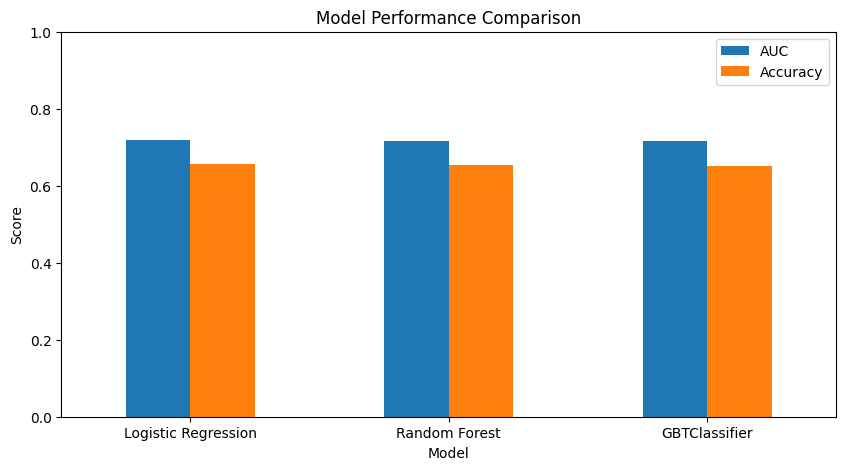

In [37]:
import matplotlib.pyplot as plt

results.plot(
    x="Model",
    y=["AUC", "Accuracy"],
    kind="bar",
    figsize=(10, 5)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.show()

In [38]:
#Feature Importance pentru Random Forest

In [39]:
#Logistic Regression

In [40]:
feature_cols_rf_old = [
    "surface_index",
    "level_index",
    "p1_hand_index",
    "p2_hand_index",
    "best_of",
    "rank_diff",
    "rank_points_diff",
    "age_diff",
    "height_diff"
]

rf_model = model_rf.stages[-1]

feature_importance = pd.DataFrame({
    "Feature": feature_cols_rf_old,
    "Importance": rf_model.featureImportances.toArray()
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
6,rank_points_diff,0.516115
5,rank_diff,0.394922
8,height_diff,0.028122
7,age_diff,0.020786
1,level_index,0.016729
4,best_of,0.011508
0,surface_index,0.005640
3,p2_hand_index,0.003241
2,p1_hand_index,0.002936


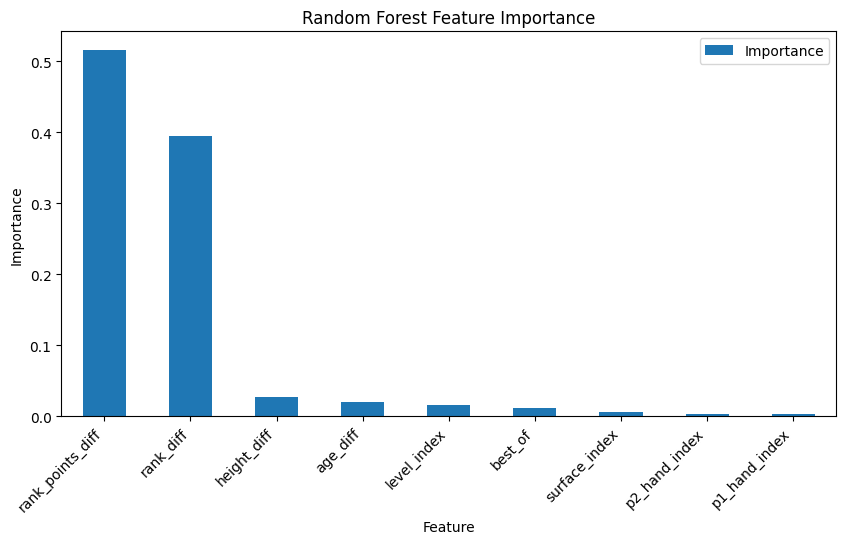

In [41]:
feature_importance.plot(
    x="Feature",
    y="Importance",
    kind="bar",
    figsize=(10, 5)
)

plt.title("Random Forest Feature Importance")
plt.ylabel("Importance")
plt.xticks(rotation=45, ha="right")
plt.show()

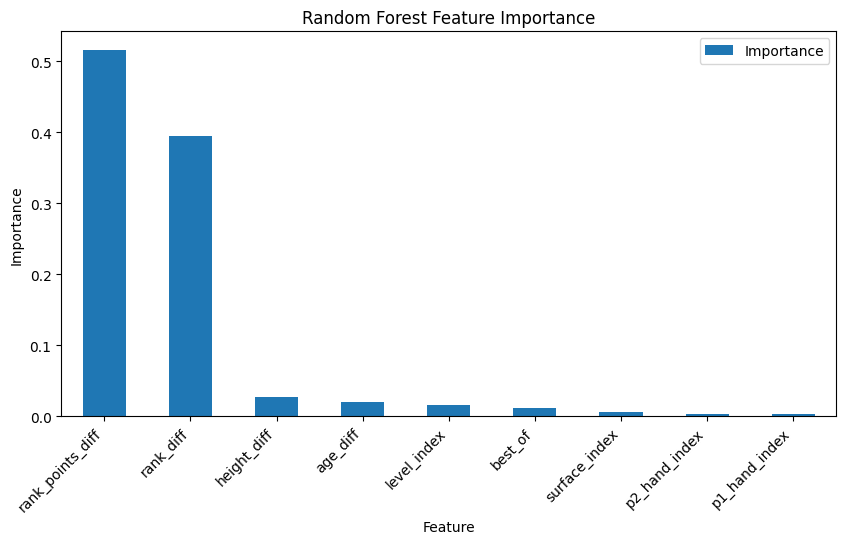

In [43]:
#GRAFIC COMPARAȚIE MODELE

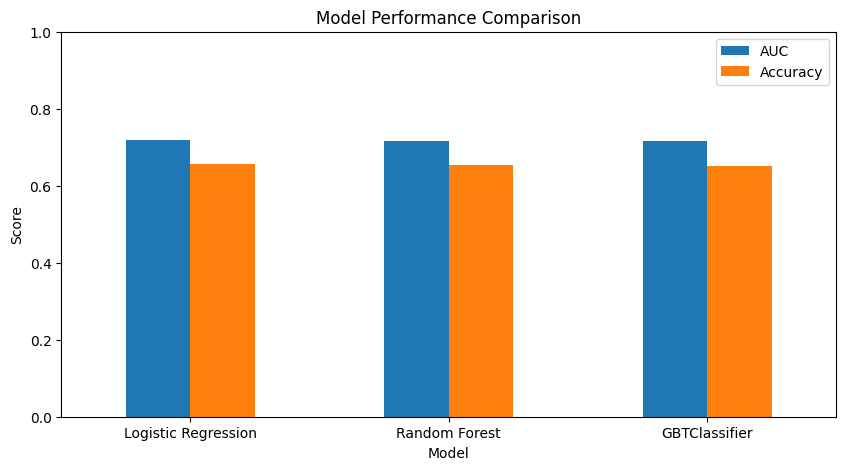

In [44]:
import matplotlib.pyplot as plt

results.plot(
    x="Model",
    y=["AUC", "Accuracy"],
    kind="bar",
    figsize=(10, 5)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)

plt.show()

In [45]:
#CROSS VALIDATION

In [46]:
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder

In [47]:
#Param grid

In [48]:
param_grid_lr = ParamGridBuilder() \
    .addGrid(lr.regParam, [0.01, 0.1, 0.5]) \
    .addGrid(lr.elasticNetParam, [0.0, 0.5, 1.0]) \
    .build()

In [49]:
#`Cross Validator

In [50]:
cv_lr = CrossValidator(
    estimator=pipeline_lr,
    estimatorParamMaps=param_grid_lr,
    evaluator=auc_evaluator,
    numFolds=3,
    parallelism=2
)

In [51]:
#Train CV model
cv_model_lr = cv_lr.fit(train)

In [52]:
#Predictions CV
pred_cv_lr = cv_model_lr.transform(test)

In [53]:
#Evaluare CV
auc_cv_lr = auc_evaluator.evaluate(pred_cv_lr)
acc_cv_lr = acc_evaluator.evaluate(pred_cv_lr)

print("Cross-Validated Logistic Regression AUC:", auc_cv_lr)
print("Cross-Validated Logistic Regression Accuracy:", acc_cv_lr) 
#Cross Validation a fost utilizata pentru a verifica stabilitatea modelului si pentru a reduce riscul obtinerii unor rezultate favorabile datorate unei impartiri particulare a datelor in seturi de antrenare si testare

Cross-Validated Logistic Regression AUC: 0.7176670921760249
Cross-Validated Logistic Regression Accuracy: 0.6545308832789513


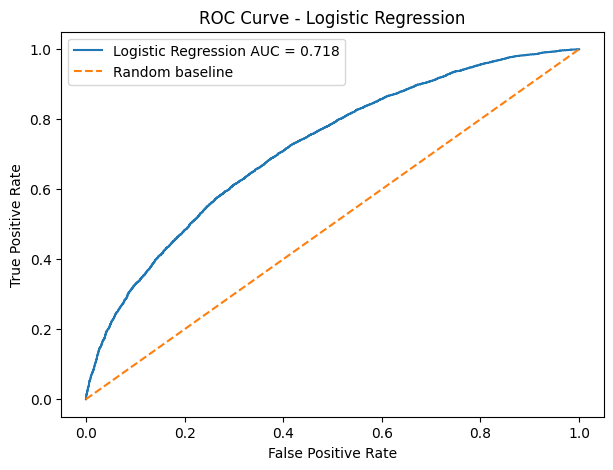

In [54]:
#ROC Curve pentru Logistic Regression
from pyspark.ml.functions import vector_to_array
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc as sklearn_auc

pred_lr_pd = pred_lr.select(
    "label",
    vector_to_array("probability")[1].alias("probability_class_1")
).toPandas()

fpr, tpr, thresholds = roc_curve(
    pred_lr_pd["label"],
    pred_lr_pd["probability_class_1"]
)

roc_auc = sklearn_auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"Logistic Regression AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random baseline")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

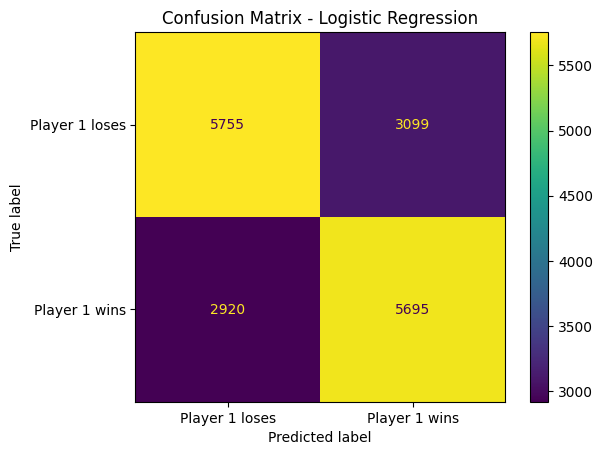

In [55]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_pd = pred_lr.select("label", "prediction").toPandas()

cm = confusion_matrix(
    cm_pd["label"],
    cm_pd["prediction"]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Player 1 loses", "Player 1 wins"]
)

disp.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [56]:
#Accuracy, Precision, Recall, F1
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

metrics = ["accuracy", "weightedPrecision", "weightedRecall", "f1"]

for metric in metrics:
    evaluator = MulticlassClassificationEvaluator(
        labelCol="label",
        predictionCol="prediction",
        metricName=metric
    )
    print(metric, ":", evaluator.evaluate(pred_lr))

accuracy : 0.6554467914591562
weightedPrecision : 0.6556086890596611
weightedRecall : 0.6554467914591562
f1 : 0.655458917795601


In [57]:


#SORTARE CRONOLOGICĂ
from pyspark.sql.functions import to_date

df_sorted = df.orderBy("tourney_date")

In [58]:
#FATIGUE SCORE
from pyspark.sql.functions import col

winner_minutes = df_sorted.select(
    col("winner_id").alias("player_id"),
    "tourney_date",
    col("minutes").alias("match_minutes")
)

loser_minutes = df_sorted.select(
    col("loser_id").alias("player_id"),
    "tourney_date",
    col("minutes").alias("match_minutes")
)

player_minutes = winner_minutes.unionByName(loser_minutes)

In [59]:
#Window function
from pyspark.sql.window import Window
from pyspark.sql.functions import sum as spark_sum

window_spec = Window.partitionBy("player_id") \
    .orderBy("tourney_date") \
    .rowsBetween(-5, -1)

In [60]:
#Fatigue score
player_minutes = player_minutes.withColumn(
    "fatigue_score",
    spark_sum("match_minutes").over(window_spec)
)

In [61]:
player_minutes.show(100)

+---------+------------+-------------+-------------+
|player_id|tourney_date|match_minutes|fatigue_score|
+---------+------------+-------------+-------------+
|   100644|    20130715|           67|         NULL|
|   100644|    20140428|           63|           67|
|   100644|    20140707|          103|          130|
|   100644|    20140714|           58|          233|
|   100644|    20140714|          120|          291|
|   100644|    20140714|          113|          411|
|   100644|    20140714|          124|          457|
|   100644|    20140714|           56|          518|
|   100644|    20140721|           86|          471|
|   100644|    20140727|           57|          499|
|   100644|    20141020|          105|          436|
|   100644|    20150209|           66|          428|
|   100644|    20150216|           86|          370|
|   100644|    20150223|           76|          400|
|   100644|    20150325|          123|          390|
|   100644|    20150325|           90|        

In [62]:
#WIN STREAK
#Winner matches
winner_results = df_sorted.select(
    col("winner_id").alias("player_id"),
    "tourney_date",
    lit(1).alias("win")
)

loser_results = df_sorted.select(
    col("loser_id").alias("player_id"),
    "tourney_date",
    lit(0).alias("win")
)

player_results = winner_results.unionByName(loser_results)

In [63]:
#Window pentru ultimele meciuri
window_results = Window.partitionBy("player_id") \
    .orderBy("tourney_date") \
    .rowsBetween(-5, -1)

In [64]:
#Win streak / recent form
from pyspark.sql.functions import avg

player_results = player_results.withColumn(
    "recent_win_rate",
    avg("win").over(window_results)
)

In [65]:
player_results.show(10)

+---------+------------+---+---------------+
|player_id|tourney_date|win|recent_win_rate|
+---------+------------+---+---------------+
|   100644|    20130715|  0|           NULL|
|   100644|    20140428|  0|            0.0|
|   100644|    20140707|  0|            0.0|
|   100644|    20140714|  1|            0.0|
|   100644|    20140714|  1|           0.25|
|   100644|    20140714|  1|            0.4|
|   100644|    20140714|  1|            0.6|
|   100644|    20140714|  0|            0.8|
|   100644|    20140721|  0|            0.8|
|   100644|    20140727|  0|            0.6|
+---------+------------+---+---------------+
only showing top 10 rows


In [66]:
#SURFACE WIN RATE

In [67]:
winner_surface = df_sorted.select(
    col("winner_id").alias("player_id"),
    "surface",
    "tourney_date",
    lit(1).alias("win")
)

loser_surface = df_sorted.select(
    col("loser_id").alias("player_id"),
    "surface",
    "tourney_date",
    lit(0).alias("win")
)

surface_results = winner_surface.unionByName(loser_surface)

In [68]:
#Window pe suprafata
surface_window = Window.partitionBy(
    "player_id",
    "surface"
).orderBy("tourney_date").rowsBetween(-10, -1)

In [69]:
#Surface win rate 
surface_results = surface_results.withColumn(
    "surface_win_rate",
    avg("win").over(surface_window)
)

In [70]:
surface_results.show(10)

+---------+-------+------------+---+------------------+
|player_id|surface|tourney_date|win|  surface_win_rate|
+---------+-------+------------+---+------------------+
|   100644|   Clay|    20130715|  0|              NULL|
|   100644|   Clay|    20140428|  0|               0.0|
|   100644|   Clay|    20140707|  0|               0.0|
|   100644|   Clay|    20140714|  1|               0.0|
|   100644|   Clay|    20140714|  1|              0.25|
|   100644|   Clay|    20140714|  1|               0.4|
|   100644|   Clay|    20140714|  1|               0.5|
|   100644|   Clay|    20140714|  0|0.5714285714285714|
|   100644|   Clay|    20140721|  0|               0.5|
|   100644|   Clay|    20140727|  0|0.4444444444444444|
+---------+-------+------------+---+------------------+
only showing top 10 rows


In [71]:
#FATIGUE PENTRU PLAYER 1 ȘI PLAYER 2

In [72]:
player1_fatigue = player_minutes.select(
    col("player_id").alias("player_1_id"),
    "tourney_date",
    col("fatigue_score").alias("player_1_fatigue")
)




player2_fatigue = player_minutes.select(
    col("player_id").alias("player_2_id"),
    "tourney_date",
    col("fatigue_score").alias("player_2_fatigue")
)

In [73]:
df_enriched = df_model_clean.join(
    player1_fatigue,
    on=["player_1_id", "tourney_date"],
    how="left"
)

df_enriched = df_enriched.join(
    player2_fatigue,
    on=["player_2_id", "tourney_date"],
    how="left"
)

In [74]:
#WIN RATE RECENT
player1_form = player_results.select(
    col("player_id").alias("player_1_id"),
    "tourney_date",
    col("recent_win_rate").alias("player_1_recent_win_rate")
)
player2_form = player_results.select(
    col("player_id").alias("player_2_id"),
    "tourney_date",
    col("recent_win_rate").alias("player_2_recent_win_rate")
)

In [75]:
#JOIN
df_enriched = df_enriched.join(
    player1_form,
    on=["player_1_id", "tourney_date"],
    how="left"
)

df_enriched = df_enriched.join(
    player2_form,
    on=["player_2_id", "tourney_date"],
    how="left"
)

In [76]:
#SURFACE WIN RATE
player1_surface = surface_results.select(
    col("player_id").alias("player_1_id"),
    "surface",
    "tourney_date",
    col("surface_win_rate").alias("player_1_surface_win_rate")
)
player2_surface = surface_results.select(
    col("player_id").alias("player_2_id"),
    "surface",
    "tourney_date",
    col("surface_win_rate").alias("player_2_surface_win_rate")
)

In [77]:
#JOIN
df_enriched = df_enriched.join(
    player1_surface,
    on=["player_1_id", "surface", "tourney_date"],
    how="left"
)

df_enriched = df_enriched.join(
    player2_surface,
    on=["player_2_id", "surface", "tourney_date"],
    how="left"
)

In [78]:
#Primele meciuri nu au istoric
df_enriched = df_enriched.fillna({
    "player_1_fatigue": 0,
    "player_2_fatigue": 0,
    "player_1_recent_win_rate": 0.5,
    "player_2_recent_win_rate": 0.5,
    "player_1_surface_win_rate": 0.5,
    "player_2_surface_win_rate": 0.5
})


df_enriched = df_enriched.withColumn(
    "fatigue_diff",
    col("player_1_fatigue") - col("player_2_fatigue")
).withColumn(
    "recent_form_diff",
    col("player_1_recent_win_rate") - col("player_2_recent_win_rate")
).withColumn(
    "surface_form_diff",
    col("player_1_surface_win_rate") - col("player_2_surface_win_rate")
)

In [79]:
df_enriched.select(
    "fatigue_diff",
    "recent_form_diff",
    "surface_form_diff"
).show(10)

+------------+----------------+-----------------+
|fatigue_diff|recent_form_diff|surface_form_diff|
+------------+----------------+-----------------+
|         378|             0.5|              0.5|
|         378|             0.5|              0.5|
|         378|             0.5|              0.5|
|         378|             0.5|              0.5|
|         378|             0.5|              0.0|
|         378|             0.5|              0.5|
|         378|             0.5|              0.5|
|         378|             0.5|              0.5|
|         378|             0.5|              0.5|
|         378|             0.5|              0.0|
+------------+----------------+-----------------+
only showing top 10 rows


In [80]:
feature_cols = [
    "surface_index",
    "level_index",
    "p1_hand_index",
    "p2_hand_index",
    "best_of",

    "rank_diff",
    "rank_points_diff",
    "age_diff",
    "height_diff",

    "fatigue_diff",
    "recent_form_diff",
    "surface_form_diff"
]

In [81]:
assembler_adv = VectorAssembler(
    inputCols=feature_cols,
    outputCol="features"
)

pipeline_lr_adv = Pipeline(stages=[
    surface_indexer,
    level_indexer,
    p1_hand_indexer,
    p2_hand_indexer,
    assembler_adv,
    lr
])

In [ ]:
#train_adv, test_adv = df_enriched.randomSplit([0.8, 0.2], seed=42)

#model_lr_adv = pipeline_lr_adv.fit(train_adv)

#pred_lr_adv = model_lr_adv.transform(test_adv)

In [ ]:
#auc_lr_adv = auc_evaluator.evaluate(pred_lr_adv)
#acc_lr_adv = acc_evaluator.evaluate(pred_lr_adv)

#print("Advanced Logistic Regression AUC:", auc_lr_adv)
#print("Advanced Logistic Regression Accuracy:", acc_lr_adv)

In [ ]:
#Home Advantage

In [ ]:
#from pyspark.sql.functions import when

#df_home = df.withColumn(
 #   "winner_home",
 #   when(col("winner_ioc") == "USA", 1, 0)
#)

#df_home.groupBy("winner_home").count().show()

In [86]:
players_df.count()

24345

In [85]:
model_lr

PipelineModel_566a34b4320e

In [82]:
players_df = df.select(
    "winner_name",
    "winner_rank",
    "winner_rank_points",
    "winner_age",
    "winner_ht"
).distinct()

In [87]:
from pyspark.sql.functions import col
from pyspark.sql import Row

def get_player_stats(player_name):

    player = players_df.filter(
        col("winner_name") == player_name
    ).orderBy(col("winner_rank").asc())

    result = player.first()

    if result is None:
        raise Exception(f"Player not found: {player_name}")

    return result

In [88]:
#Pentru a prezice sansele unui jucator impotriva altuia
from pyspark.sql import Row

def predict_match(player1_name, player2_name, surface):

    p1 = get_player_stats(player1_name)
    p2 = get_player_stats(player2_name)

    rank_diff = p1["winner_rank"] - p2["winner_rank"]
    rank_points_diff = (
        p1["winner_rank_points"]
        - p2["winner_rank_points"]
    )

    age_diff = (
        p1["winner_age"]
        - p2["winner_age"]
    )

    height_diff = (
        p1["winner_ht"]
        - p2["winner_ht"]
    )

    match_df = spark.createDataFrame([Row(
        surface=surface,
        tourney_level="G",
        best_of=5,
        player_1_hand="R",
        player_2_hand="R",
        rank_diff=rank_diff,
        rank_points_diff=rank_points_diff,
        age_diff=age_diff,
        height_diff=height_diff
    )])

    prediction = model_lr.transform(match_df)

    prob = prediction.select(
        "probability"
    ).first()[0][1]

    print(f"{player1_name}: {prob*100:.2f}%")
    print(f"{player2_name}: {(1-prob)*100:.2f}%")

    if prob > 0.5:
        print("Predicted winner:", player1_name)
    else:
        print("Predicted winner:", player2_name)

In [89]:
predict_match(
    "Novak Djokovic",
    "Carlos Alcaraz",
    "Hard"
)

Novak Djokovic: 89.12%
Carlos Alcaraz: 10.88%
Predicted winner: Novak Djokovic


In [90]:
predict_match(
    "Jannik Sinner",
    "Carlos Alcaraz",
    "Hard"
)

Jannik Sinner: 71.05%
Carlos Alcaraz: 28.95%
Predicted winner: Jannik Sinner


In [91]:
predict_match(
    "Jannik Sinner",
    "Carlos Alcaraz",
    "Clay"
)

Jannik Sinner: 71.13%
Carlos Alcaraz: 28.87%
Predicted winner: Jannik Sinner


In [ ]:
#H2H  Head to head
#pt a masura istoricul dintre doi jucatori, fara a include si meciul actual

In [94]:
from pyspark.sql.functions import monotonically_increasing_id
#adaug un id pt a adauga H2H pe acelasi rand pentru a face join
df_model_h2h_base = df_model_clean.withColumn(
    "match_row_id",
    monotonically_increasing_id()
)

df_model_h2h_base.select(
    "match_row_id",
    "tourney_date",
    "player_1_id",
    "player_2_id",
    "label"
).show(5)

+------------+------------+-----------+-----------+-----+
|match_row_id|tourney_date|player_1_id|player_2_id|label|
+------------+------------+-----------+-----------+-----+
|           0|    20100103|     104053|     103429|    1|
|           1|    20100103|     104958|     104999|    1|
|           2|    20100103|     104755|     103813|    1|
|           3|    20100103|     105051|     103781|    1|
|           4|    20100103|     104607|     105194|    1|
+------------+------------+-----------+-----------+-----+
only showing top 5 rows


In [95]:
#construire istoric
from pyspark.sql.functions import col, least, greatest, when, count
from pyspark.sql.functions import sum as spark_sum

h2h_history = df.select(
    col("tourney_date"),
    col("winner_id"),
    col("loser_id")
).dropna(subset=[
    "tourney_date",
    "winner_id",
    "loser_id"
])

h2h_history = h2h_history.withColumn(
    "player_low_id",
    least(col("winner_id"), col("loser_id"))
).withColumn(
    "player_high_id",
    greatest(col("winner_id"), col("loser_id"))
)

h2h_history.show(5)

+------------+---------+--------+-------------+--------------+
|tourney_date|winner_id|loser_id|player_low_id|player_high_id|
+------------+---------+--------+-------------+--------------+
|    20100103|   104053|  103429|       103429|        104053|
|    20100103|   104958|  104999|       104958|        104999|
|    20100103|   104755|  103813|       103813|        104755|
|    20100103|   105051|  103781|       103781|        105051|
|    20100103|   104607|  105194|       104607|        105194|
+------------+---------+--------+-------------+--------------+
only showing top 5 rows


In [96]:
#pregatire perechi
df_pairs = df_model_h2h_base.select(
    "match_row_id",
    "tourney_date",
    "player_1_id",
    "player_2_id"
).withColumn(
    "player_low_id",
    least(col("player_1_id"), col("player_2_id"))
).withColumn(
    "player_high_id",
    greatest(col("player_1_id"), col("player_2_id"))
)

df_pairs.show(5)

+------------+------------+-----------+-----------+-------------+--------------+
|match_row_id|tourney_date|player_1_id|player_2_id|player_low_id|player_high_id|
+------------+------------+-----------+-----------+-------------+--------------+
|           0|    20100103|     104053|     103429|       103429|        104053|
|           1|    20100103|     104958|     104999|       104958|        104999|
|           2|    20100103|     104755|     103813|       103813|        104755|
|           3|    20100103|     105051|     103781|       103781|        105051|
|           4|    20100103|     104607|     105194|       104607|        105194|
+------------+------------+-----------+-----------+-------------+--------------+
only showing top 5 rows


In [97]:
#join cu meciurile anterioare
h2h_history_renamed = h2h_history.select(
    col("tourney_date").alias("history_date"),
    "winner_id",
    "loser_id",
    "player_low_id",
    "player_high_id"
)

h2h_joined = df_pairs.join(
    h2h_history_renamed,
    on=["player_low_id", "player_high_id"],
    how="left"
).filter(
    col("history_date").isNull() |
    (col("history_date") < col("tourney_date"))
)

h2h_joined.select(
    "match_row_id",
    "tourney_date",
    "history_date",
    "player_1_id",
    "player_2_id",
    "winner_id",
    "loser_id"
).show(10)

+------------+------------+------------+-----------+-----------+---------+--------+
|match_row_id|tourney_date|history_date|player_1_id|player_2_id|winner_id|loser_id|
+------------+------------+------------+-----------+-----------+---------+--------+
|         115|    20100111|    20100104|     103808|     104523|   103808|  104523|
|         140|    20100111|    20100103|     104571|     103888|   104571|  103888|
|         238|    20100118|    20100111|     103720|     104571|   104571|  103720|
|         247|    20100118|    20100104|     105227|     104527|   105227|  104527|
|         261|    20100118|    20100104|     103819|     103786|   103786|  103819|
|         403|    20100208|    20100118|     104925|     103843|   104925|  103843|
|         441|    20100208|    20100103|     104053|     104607|   104053|  104607|
|         463|    20100215|    20100208|     103507|     103672|   103507|  103672|
|         464|    20100215|    20100118|     103970|     104523|   103970|  

In [98]:
#calc victorii pentru cei doi jucatori 
h2h_stats = h2h_joined.groupBy("match_row_id").agg(
    count("history_date").alias("h2h_total_matches"),
    spark_sum(
        when(col("winner_id") == col("player_1_id"), 1).otherwise(0)
    ).alias("h2h_wins_player_1"),
    spark_sum(
        when(col("winner_id") == col("player_2_id"), 1).otherwise(0)
    ).alias("h2h_wins_player_2")
)

h2h_stats.show(10)

+------------+-----------------+-----------------+-----------------+
|match_row_id|h2h_total_matches|h2h_wins_player_1|h2h_wins_player_2|
+------------+-----------------+-----------------+-----------------+
|         474|                1|                1|                0|
|         849|                1|                1|                0|
|         895|                1|                1|                0|
|        1044|                1|                1|                0|
|        1046|                2|                2|                0|
|        1107|                1|                1|                0|
|        1111|                1|                1|                0|
|        1253|                1|                0|                1|
|        1283|                1|                1|                0|
|        1315|                3|                2|                1|
+------------+-----------------+-----------------+-----------------+
only showing top 10 rows


In [99]:
h2h_stats = h2h_stats.withColumn(
    "h2h_win_rate_player_1",
    when(
        col("h2h_total_matches") > 0,
        col("h2h_wins_player_1") / col("h2h_total_matches")
    ).otherwise(0.5)
)

h2h_stats.select(
    "match_row_id",
    "h2h_total_matches",
    "h2h_wins_player_1",
    "h2h_wins_player_2",
    "h2h_win_rate_player_1"
).show(10)

+------------+-----------------+-----------------+-----------------+---------------------+
|match_row_id|h2h_total_matches|h2h_wins_player_1|h2h_wins_player_2|h2h_win_rate_player_1|
+------------+-----------------+-----------------+-----------------+---------------------+
|         474|                1|                1|                0|                  1.0|
|         849|                1|                1|                0|                  1.0|
|         895|                1|                1|                0|                  1.0|
|        1044|                1|                1|                0|                  1.0|
|        1046|                2|                2|                0|                  1.0|
|        1107|                1|                1|                0|                  1.0|
|        1111|                1|                1|                0|                  1.0|
|        1253|                1|                0|                1|                  0.0|

In [100]:
df_model_with_h2h = df_model_h2h_base.join(
    h2h_stats,
    on="match_row_id",
    how="left"
).fillna({
    "h2h_total_matches": 0,
    "h2h_wins_player_1": 0,
    "h2h_wins_player_2": 0,
    "h2h_win_rate_player_1": 0.5
})

df_model_with_h2h.select(
    "tourney_date",
    "player_1_id",
    "player_2_id",
    "label",
    "h2h_total_matches",
    "h2h_wins_player_1",
    "h2h_wins_player_2",
    "h2h_win_rate_player_1"
).show(10)

#Pentru situatiile in care doi jucatori nu se intalnisera anterior, valoarea caracteristicii H2H a fost setata la 0.5, reprezentand o situatie neutra in care niciun jucator nu are avantaj istoric

+------------+-----------+-----------+-----+-----------------+-----------------+-----------------+---------------------+
|tourney_date|player_1_id|player_2_id|label|h2h_total_matches|h2h_wins_player_1|h2h_wins_player_2|h2h_win_rate_player_1|
+------------+-----------+-----------+-----+-----------------+-----------------+-----------------+---------------------+
|    20100103|     104755|     103813|    1|                0|                0|                0|                  0.5|
|    20100103|     102967|     104332|    1|                0|                0|                0|                  0.5|
|    20100103|     105051|     103781|    1|                0|                0|                0|                  0.5|
|    20100103|     105064|     103428|    1|                0|                0|                0|                  0.5|
|    20100103|     104607|     105194|    1|                0|                0|                0|                  0.5|
|    20100103|     104571|     1

In [101]:
print("Rows before H2H:", df_model_clean.count())
print("Rows after H2H:", df_model_with_h2h.count())

df_model_with_h2h.select(
    "h2h_total_matches",
    "h2h_win_rate_player_1"
).describe().show()

Rows before H2H: 87680
Rows after H2H: 87680
+-------+------------------+---------------------+
|summary| h2h_total_matches|h2h_win_rate_player_1|
+-------+------------------+---------------------+
|  count|             87680|                87680|
|   mean|1.1375912408759123|   0.5000000000000028|
| stddev|2.1658345512191706|  0.28275809203164565|
|    min|                 0|                  0.0|
|    max|                38|                  1.0|
+-------+------------------+---------------------+



In [102]:
#df_features cu H2H inclus
df_features = df_model_with_h2h.withColumn(
    "rank_diff",
    col("player_1_rank") - col("player_2_rank")
).withColumn(
    "rank_points_diff",
    col("player_1_rank_points") - col("player_2_rank_points")
).withColumn(
    "age_diff",
    col("player_1_age") - col("player_2_age")
).withColumn(
    "height_diff",
    col("player_1_ht") - col("player_2_ht")
)

df_features.select(
    "surface",
    "tourney_level",
    "best_of",
    "rank_diff",
    "rank_points_diff",
    "age_diff",
    "height_diff",
    "h2h_win_rate_player_1",
    "label"
).show(10)

+-------+-------------+-------+---------+----------------+------------------+-----------+---------------------+-----+
|surface|tourney_level|best_of|rank_diff|rank_points_diff|          age_diff|height_diff|h2h_win_rate_player_1|label|
+-------+-------------+-------+---------+----------------+------------------+-----------+---------------------+-----+
|   Hard|            A|      3|      -36|             282|-4.899999999999999|          0|                  0.5|    1|
|   Hard|            A|      3|      -22|             157|7.0000000000000036|          3|                  0.5|    1|
|   Hard|            A|      3|      257|           -1109|              -6.5|          5|                  0.5|    1|
|   Hard|            A|      3|      -37|             410|              -8.3|         -2|                  0.5|    1|
|   Hard|            A|      3|     -231|            1476|2.8000000000000007|         13|                  0.5|    1|
|   Hard|            A|      3|      -13|             15

In [105]:
feature_cols = [
    "surface_index",
    "level_index",
    "p1_hand_index",
    "p2_hand_index",
    "best_of",
    "rank_diff",
    "rank_points_diff",
    "age_diff",
    "height_diff",
    "h2h_win_rate_player_1"
]

In [106]:


#reantrenare modele 
assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol="features"
)

In [108]:
#logistic regression
pipeline_lr = Pipeline(stages=[
    surface_indexer,
    level_indexer,
    p1_hand_indexer,
    p2_hand_indexer,
    assembler,
    lr
])

In [109]:
#train/test split
train, test = df_features.randomSplit([0.8, 0.2], seed=42)

print("Train:", train.count())
print("Test:", test.count())

Train: 70377
Test: 17303


In [110]:
#reantrenare logistic regr
model_lr = pipeline_lr.fit(train)

pred_lr = model_lr.transform(test)

In [111]:
auc_h2h = auc_evaluator.evaluate(pred_lr)
acc_h2h = acc_evaluator.evaluate(pred_lr)

print("Logistic Regression + H2H AUC:", auc_h2h)
print("Logistic Regression + H2H Accuracy:", acc_h2h)

Logistic Regression + H2H AUC: 0.7143252080483588
Logistic Regression + H2H Accuracy: 0.6531237357683639


In [ ]:
#H2H nu a imbunatatit modelul pentru acest dataset

In [112]:
results_h2h = pd.DataFrame({
    "Model": [
        "Logistic Regression Basic",
        "Logistic Regression + H2H"
    ],
    "AUC": [
        auc,
        auc_h2h
    ],
    "Accuracy": [
        acc,
        acc_h2h
    ]
})

results_h2h

,Model,AUC,Accuracy
0,Logistic Regression Basic,0.718109,0.655447
1,Logistic Regression + H2H,0.714325,0.653124


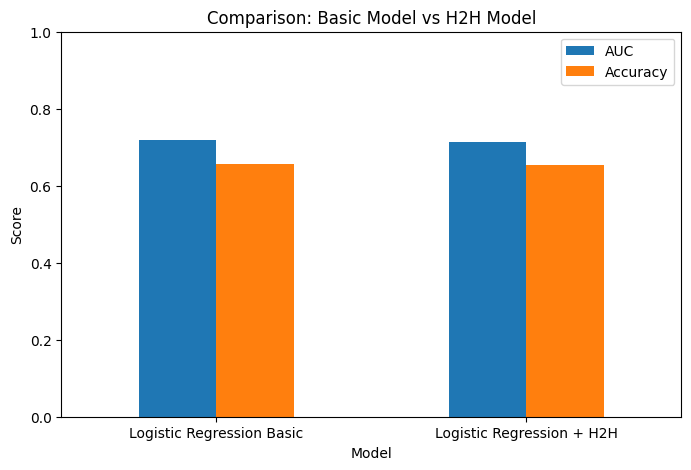

In [113]:
results_h2h.plot(
    x="Model",
    y=["AUC", "Accuracy"],
    kind="bar",
    figsize=(8, 5)
)

plt.title("Comparison: Basic Model vs H2H Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.show()

In [114]:
final_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "GBT",
        "Logistic Regression + H2H"
    ],
    "AUC": [
        auc,
        auc_rf,
        auc_gbt,
        auc_h2h
    ],
    "Accuracy": [
        acc,
        acc_rf,
        acc_gbt,
        acc_h2h
    ]
})

final_results

,Model,AUC,Accuracy
0,Logistic Regression,0.718109,0.655447
1,Random Forest,0.716705,0.654531
2,GBT,0.716979,0.652413
3,Logistic Regression + H2H,0.714325,0.653124


In [128]:
from pyspark.sql import Row

def predict_match(player1_name, player2_name, surface, tourney_level="G", best_of=5):

    p1 = get_player_stats(player1_name)
    p2 = get_player_stats(player2_name)

    rank_diff = p1["winner_rank"] - p2["winner_rank"]
    rank_points_diff = p1["winner_rank_points"] - p2["winner_rank_points"]
    age_diff = p1["winner_age"] - p2["winner_age"]
    height_diff = p1["winner_ht"] - p2["winner_ht"]

    match_df = spark.createDataFrame([Row(
        surface=surface,
        tourney_level=tourney_level,
        best_of=best_of,
        player_1_hand="R",
        player_2_hand="R",
        rank_diff=rank_diff,
        rank_points_diff=rank_points_diff,
        age_diff=age_diff,
        height_diff=height_diff,
        h2h_win_rate_player_1=0.5
    )])

    prediction = model_lr.transform(match_df)

    prob = prediction.select("probability").first()[0][1]

    print("Match prediction")
    print(f"{player1_name}: {prob*100:.2f}%")
    print(f"{player2_name}: {(1-prob)*100:.2f}%")

    if prob > 0.5:
        print("Predicted winner:", player1_name)
    else:
        print("Predicted winner:", player2_name)

In [129]:
predict_match(
    "Novak Djokovic",
    "Carlos Alcaraz",
    "Hard",
    tourney_level="G",
    best_of=5
)

Match prediction
Novak Djokovic: 87.44%
Carlos Alcaraz: 12.56%
Predicted winner: Novak Djokovic


In [132]:
predict_match(
    "Roger Federer",   
    "Novak Djokovic",
    "Clay",
    tourney_level="G",
    best_of=5
)

Match prediction
Roger Federer: 31.11%
Novak Djokovic: 68.89%
Predicted winner: Novak Djokovic


In [133]:
predict_match(
    "Roger Federer",   
    "Alexander Zverev",
    "Clay",
    tourney_level="G",
    best_of=5
)

Match prediction
Roger Federer: 73.27%
Alexander Zverev: 26.73%
Predicted winner: Roger Federer
